In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv("driving_risk_dataset_1500_rows.csv")

print(df.head())
print(df.shape)


   Maximum_speed (km/h)  Average_speed (km/h)  Std_speed  Avg_acc (m/s^2)  \
0                 81.31                 48.97      17.21             0.79   
1                 65.94                 39.12      16.76            -0.22   
2                105.89                 81.13      11.69            -0.30   
3                 63.62                 37.90      14.74            -0.42   
4                 48.14                 25.81      12.59             2.13   

   Std_acc  Mean_pos_acc  Mean_neg_acc  Avg_abs_jerk  Std_abs_jerk  \
0     0.51          1.43         -1.02          2.15          0.84   
1     0.59          1.08         -1.54          1.47          1.10   
2     0.30          1.63         -1.15          2.09          1.10   
3     0.50          1.55         -1.42          2.00          0.94   
4     0.54          1.26         -1.29          1.59          1.09   

   Brake_time_pct  Acc_time_pct  Decel_time_pct  Const_speed_pct  
0           19.01         27.08           28.15  

In [4]:
def classify_risk(row):
    score = 0
    
    if row["Maximum_speed (km/h)"] > 110:
        score += 2
    if row["Brake_time_pct"] > 20:
        score += 2
    if row["Avg_abs_jerk"] > 3:
        score += 2
    if row["Std_speed"] > 15:
        score += 1
    if row["Mean_neg_acc"] < -2:
        score += 1
        
    if score >= 4:
        return 2
    elif score >= 2:
        return 1
    else:
        return 0


df["risk_label"] = df.apply(classify_risk, axis=1)

print(df["risk_label"].value_counts())


risk_label
0    769
1    603
2    128
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("risk_label", axis=1)
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [6]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [7]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)
print("Classification Report:")
print(classification_report(y_test, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       154
           1       0.98      0.97      0.98       120
           2       1.00      0.92      0.96        26

    accuracy                           0.98       300
   macro avg       0.99      0.97      0.98       300
weighted avg       0.98      0.98      0.98       300

Confusion Matrix:
[[154   0   0]
 [  3 117   0]
 [  0   2  24]]


In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())


Cross-validation accuracy: 0.9866666666666667


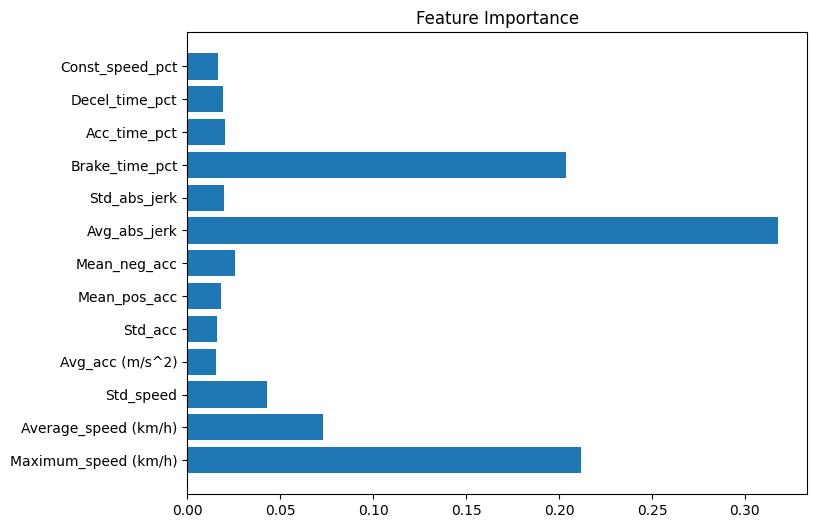

In [10]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()


In [11]:

extreme_sample = pd.DataFrame([{
    "Maximum_speed (km/h)": 135,
    "Average_speed (km/h)": 110,
    "Std_speed": 30,
    "Avg_acc (m/s^2)": 2.8,
    "Std_acc": 1.5,
    "Mean_pos_acc": 3.5,
    "Mean_neg_acc": -3.5,
    "Avg_abs_jerk": 6.5,
    "Std_abs_jerk": 3.0,
    "Brake_time_pct": 35,
    "Acc_time_pct": 40,
    "Decel_time_pct": 35,
    "Const_speed_pct": 25
}])

print(model.predict(extreme_sample))



[2]


In [12]:
feature_explanations = {

    "Maximum_speed (km/h)": {
        "high": "Vehicle reached excessively high maximum speeds, significantly increasing crash severity risk.",
        "medium": "Maximum speed exceeded optimal safety thresholds.",
        "low": "Maximum speed remained within safe operational limits."
    },

    "Average_speed (km/h)": {
        "high": "Sustained high average speeds indicate aggressive driving over time.",
        "medium": "Average speed was moderately high during the trip.",
        "low": "Average speed remained within safe driving limits."
    },

    "Std_speed": {
        "high": "Significant speed fluctuations indicate unstable speed control.",
        "medium": "Noticeable speed variation suggests inconsistent driving.",
        "low": "Speed was maintained consistently with minimal variation."
    },

    "Avg_acc (m/s^2)": {
        "high": "Frequent aggressive acceleration increases collision and fuel risk.",
        "medium": "Acceleration patterns show moderate aggressiveness.",
        "low": "Acceleration was smooth and controlled."
    },

    "Std_acc": {
        "high": "Acceleration variability suggests unstable throttle control.",
        "medium": "Acceleration patterns show occasional instability.",
        "low": "Acceleration behavior remained stable."
    },

    "Mean_pos_acc": {
        "high": "Frequent strong acceleration bursts were detected.",
        "medium": "Acceleration bursts occurred occasionally.",
        "low": "Acceleration bursts were minimal and controlled."
    },

    "Mean_neg_acc": {
        "high": "Harsh braking intensity was excessive, increasing collision probability.",
        "medium": "Braking force was occasionally strong.",
        "low": "Braking intensity remained within safe limits."
    },

    "Avg_abs_jerk": {
        "high": "Sudden acceleration and braking movements indicate unstable driving behavior.",
        "medium": "Some abrupt driving movements were detected.",
        "low": "Smooth acceleration and braking patterns were maintained."
    },

    "Std_abs_jerk": {
        "high": "High jerk variability suggests inconsistent pedal control.",
        "medium": "Moderate driving abruptness was observed.",
        "low": "Driving inputs remained smooth."
    },

    "Brake_time_pct": {
        "high": "Frequent and aggressive braking suggests unsafe driving patterns.",
        "medium": "Moderate braking frequency indicates inconsistent speed control.",
        "low": "Controlled braking behavior contributes to safer driving."
    },

    "Acc_time_pct": {
        "high": "Excessive acceleration duration increases fuel and mechanical stress.",
        "medium": "Acceleration time was slightly elevated.",
        "low": "Acceleration time remained within normal limits."
    },

    "Decel_time_pct": {
        "high": "Frequent deceleration indicates unstable traffic response.",
        "medium": "Moderate deceleration frequency observed.",
        "low": "Deceleration was balanced and controlled."
    },

    "Const_speed_pct": {
        "high": "Low constant speed percentage suggests unstable driving rhythm.",
        "medium": "Speed consistency could be improved.",
        "low": "Vehicle maintained steady speeds effectively."
    }
}

In [14]:
label_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}


for i, pred in enumerate(predictions):
    class_index = list(model.classes_).index(pred)
    confidence = probabilities[i][class_index]

    
    
    print("\n----------------------------------")
    print(f"Sample {i+1}")
    print(f"Risk Level: {label_map[pred]}")
    print(f"Confidence: {confidence:.2f}")


    contributions = dict(
       zip(X.columns, shap_values[i][:, class_index])

    )


    sorted_features = sorted(
        contributions.items(),
        key=lambda x: abs(x[1]),
        reverse=True
    )


    # Determine risk category
    if pred == 2:
        risk_category = "high"
        print("\nThis driver is classified as HIGH RISK because:")
    elif pred == 1:
        risk_category = "medium"
        print("\nThis driver is classified as MEDIUM RISK due to:")
    else:
        risk_category = "low"
        print("\nThis driver is classified as LOW RISK as:")


    count = 0


    for feature, value in sorted_features:
        if feature in feature_explanations:
            explanation_text = feature_explanations[feature][risk_category]
            print(f" • {explanation_text}")
            count += 1
        if count == 3:
            break




----------------------------------
Sample 1
Risk Level: Low Risk
Confidence: 1.00

This driver is classified as LOW RISK as:
 • Smooth acceleration and braking patterns were maintained.
 • Controlled braking behavior contributes to safer driving.
 • Maximum speed remained within safe operational limits.

----------------------------------
Sample 2
Risk Level: Low Risk
Confidence: 1.00

This driver is classified as LOW RISK as:
 • Controlled braking behavior contributes to safer driving.
 • Smooth acceleration and braking patterns were maintained.
 • Speed was maintained consistently with minimal variation.

----------------------------------
Sample 3
Risk Level: Medium Risk
Confidence: 0.85

This driver is classified as MEDIUM RISK due to:
 • Maximum speed exceeded optimal safety thresholds.
 • Some abrupt driving movements were detected.
 • Moderate braking frequency indicates inconsistent speed control.

----------------------------------
Sample 4
Risk Level: High Risk
Confidence: 0

In [15]:
import joblib
joblib.dump(model,"driving_risk_model.pkl")

['driving_risk_model.pkl']